<a href="https://colab.research.google.com/github/ArifaJannat2497/Python_Google_Colab/blob/Customer-Churn-analysis/Customer_Churn_Analysis_(PDSML_Day_11%2C_Exploratory_Descriptive_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Analysis

# PDSML Day-2 👉 Importing Libraries and Dataset


## Importing the essential libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import shap

## Importing the dataset


In [ ]:
dataset = pd.read_csv('Customer-Churn.csv')

# PDSML Day-3 👉 Data Preprocessing (Part-1)


### Checking the head of the dataset


In [ ]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Checking the shape of the dataset


In [ ]:
dataset.shape

(7043, 21)

In [ ]:
dataset.head(), dataset.shape

(   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
 0  7590-VHVEG  Female              0     Yes         No       1           No   
 1  5575-GNVDE    Male              0      No         No      34          Yes   
 2  3668-QPYBK    Male              0      No         No       2          Yes   
 3  7795-CFOCW    Male              0      No         No      45           No   
 4  9237-HQITU  Female              0      No         No       2          Yes   
 
       MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
 0  No phone service             DSL             No  ...               No   
 1                No             DSL            Yes  ...              Yes   
 2                No             DSL            Yes  ...               No   
 3  No phone service             DSL            Yes  ...              Yes   
 4                No     Fiber optic             No  ...               No   
 
   TechSupport StreamingTV StreamingMovies      

### Checking how imbalanced your dataset is

In [ ]:
dataset['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


### Data cleaning


#### Detecting the erroneous numeric columns by calculating the mean

In [ ]:
print(dataset['tenure'].mean())

32.37114865824223


In [ ]:
print(dataset['MonthlyCharges'].mean())

64.76169246059918


#### Converting the string entries to numeric and nan

In [ ]:
# print(dataset['TotalCharges'].mean())

In [ ]:
dataset['TotalCharges'].iloc[3331]

' '

#### Detecting the nan entries using iloc


In [ ]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

In [ ]:
print(dataset['TotalCharges'].iloc[3331])

nan


#### Dropping the nan-containing rows from the dataframe


In [ ]:
dataset.shape

(7043, 21)

In [ ]:
dataset = dataset.dropna(subset=['TotalCharges']).copy()

In [ ]:
dataset.shape

(7032, 21)

# PDSML Day-4 👉 Data Preprocessing (Part-2)


### Removing unnecessary features


In [ ]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
list(dataset.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [ ]:
X = dataset.drop(columns=['customerID', 'Churn'])
# ['Item1', 'Item2', ......] ----->Means a list

In [ ]:
list(X.columns)

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [ ]:
print(X.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [ ]:
X.shape

(7032, 19)

### Dependent variable declaration


In [ ]:
print(dataset['Churn'].head())

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object


In [ ]:
y = dataset['Churn']

In [ ]:
y.map({'No': 0, 'Yes': 1,}) # {} ----> Means Dictionary Data Structure

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [ ]:
y = y.map({'No': 0, 'Yes': 1,})

In [ ]:
print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64


### Splitting the dataset into the training set and the test set


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

In [ ]:
print(X_train.head())

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
1413    Male              0     Yes        Yes      65          Yes   
7003    Male              0      No         No      26           No   
3355  Female              0     Yes         No      68          Yes   
4494    Male              0      No         No       3          Yes   
3541  Female              0     Yes         No      49           No   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
1413               Yes     Fiber optic            Yes          Yes   
7003  No phone service             DSL             No           No   
3355               Yes     Fiber optic             No          Yes   
4494                No     Fiber optic             No          Yes   
3541  No phone service             DSL            Yes           No   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
1413              Yes         Yes          No              No        Tw

In [ ]:
y.value_counts(normalize = True)

,proportion
Churn,
0,0.734215
1,0.265785


In [ ]:
y_test.value_counts(normalize = True)

,proportion
Churn,
0,0.734186
1,0.265814


In [ ]:
y_train.value_counts(normalize = True)


,proportion
Churn,
0,0.734222
1,0.265778


# PDSML Day-5 👉 Data Preprocessing (Part-3)


### One-hot encoding

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#### Selecting the numeric columns


In [ ]:
num_cols = X.select_dtypes(include = np.number).columns.tolist()

In [ ]:
print(num_cols)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


#### Selecting the categorical columns

In [ ]:
cat_cols = X.select_dtypes(exclude = np.number).columns.tolist()

In [ ]:
print(cat_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#### Column transformations


In [ ]:
# pre-processing
pre = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output= False), cat_cols),
        ("num", 'passthrough', num_cols)

    ]
)

In [ ]:
print(pre.fit_transform(X))

[[1.0000e+00 0.0000e+00 0.0000e+00 ... 1.0000e+00 2.9850e+01 2.9850e+01]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 3.4000e+01 5.6950e+01 1.8895e+03]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 2.0000e+00 5.3850e+01 1.0815e+02]
 ...
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 1.1000e+01 2.9600e+01 3.4645e+02]
 [0.0000e+00 1.0000e+00 0.0000e+00 ... 4.0000e+00 7.4400e+01 3.0660e+02]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 6.6000e+01 1.0565e+02 6.8445e+03]]


In [ ]:
# updated X
# X = pre.fit_transform(X)

In [ ]:
# print(X)

# PDSML Day-6 👉 Data Preprocessing (Part-4)


### Getting names of encoded categorical columns


In [ ]:
#cat_independent_variavles_names (cat_iv_names)
cat_iv_names = pre.named_transformers_['cat'].get_feature_names_out(cat_cols)

In [ ]:
print(cat_iv_names)

['gender_Female' 'gender_Male' 'Partner_No' 'Partner_Yes' 'Dependents_No'
 'Dependents_Yes' 'PhoneService_No' 'PhoneService_Yes' 'MultipleLines_No'
 'MultipleLines_No phone service' 'MultipleLines_Yes'
 'InternetService_DSL' 'InternetService_Fiber optic' 'InternetService_No'
 'OnlineSecurity_No' 'OnlineSecurity_No internet service'
 'OnlineSecurity_Yes' 'OnlineBackup_No' 'OnlineBackup_No internet service'
 'OnlineBackup_Yes' 'DeviceProtection_No'
 'DeviceProtection_No internet service' 'DeviceProtection_Yes'
 'TechSupport_No' 'TechSupport_No internet service' 'TechSupport_Yes'
 'StreamingTV_No' 'StreamingTV_No internet service' 'StreamingTV_Yes'
 'StreamingMovies_No' 'StreamingMovies_No internet service'
 'StreamingMovies_Yes' 'Contract_Month-to-month' 'Contract_One year'
 'Contract_Two year' 'PaperlessBilling_No' 'PaperlessBilling_Yes'
 'PaymentMethod_Bank transfer (automatic)'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check']


### Combining the categorical columns with the numeric columns

In [ ]:
print(num_cols)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
all_iv_names = list(cat_iv_names) + num_cols

In [ ]:
print(all_iv_names)

['gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'Payment

### Converting the transformed output to a DataFrame

In [ ]:
X_transformed = pre.fit_transform(X)

In [ ]:
print(X_transformed)

[[1.0000e+00 0.0000e+00 0.0000e+00 ... 1.0000e+00 2.9850e+01 2.9850e+01]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 3.4000e+01 5.6950e+01 1.8895e+03]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 2.0000e+00 5.3850e+01 1.0815e+02]
 ...
 [1.0000e+00 0.0000e+00 0.0000e+00 ... 1.1000e+01 2.9600e+01 3.4645e+02]
 [0.0000e+00 1.0000e+00 0.0000e+00 ... 4.0000e+00 7.4400e+01 3.0660e+02]
 [0.0000e+00 1.0000e+00 1.0000e+00 ... 6.6000e+01 1.0565e+02 6.8445e+03]]


In [ ]:
#transformed dataframe (tr_df)
tr_df = pd.DataFrame(X_transformed, columns = all_iv_names)
pd.set_option('display.max_columns', None)
print(tr_df.head())

   gender_Female  gender_Male  Partner_No  Partner_Yes  Dependents_No  \
0            1.0          0.0         0.0          1.0            1.0   
1            0.0          1.0         1.0          0.0            1.0   
2            0.0          1.0         1.0          0.0            1.0   
3            0.0          1.0         1.0          0.0            1.0   
4            1.0          0.0         1.0          0.0            1.0   

   Dependents_Yes  PhoneService_No  PhoneService_Yes  MultipleLines_No  \
0             0.0              1.0               0.0               0.0   
1             0.0              0.0               1.0               1.0   
2             0.0              0.0               1.0               1.0   
3             0.0              1.0               0.0               0.0   
4             0.0              0.0               1.0               1.0   

   MultipleLines_No phone service  MultipleLines_Yes  InternetService_DSL  \
0                             1.0      

In [ ]:
print(tr_df)

      gender_Female  gender_Male  Partner_No  Partner_Yes  Dependents_No  \
0               1.0          0.0         0.0          1.0            1.0   
1               0.0          1.0         1.0          0.0            1.0   
2               0.0          1.0         1.0          0.0            1.0   
3               0.0          1.0         1.0          0.0            1.0   
4               1.0          0.0         1.0          0.0            1.0   
...             ...          ...         ...          ...            ...   
7027            0.0          1.0         0.0          1.0            0.0   
7028            1.0          0.0         0.0          1.0            0.0   
7029            1.0          0.0         0.0          1.0            0.0   
7030            0.0          1.0         0.0          1.0            1.0   
7031            0.0          1.0         1.0          0.0            1.0   

      Dependents_Yes  PhoneService_No  PhoneService_Yes  MultipleLines_No  \
0         

# PDSML Day-8 👉 Training the Baseline Model and Evaluation


### Training the baseline model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [ ]:
pipe_lr = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter = 3000, class_weight='balanced'))
])

pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

# PDSML Day-9 👉 Model Evaluation (Part 1)

In [ ]:
print(X_test.shape)

(1407, 19)


In [ ]:
print(X_train.shape)

(5625, 19)


In [ ]:
print(X_test.head(10))

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
974   Female              0     Yes        Yes      59          Yes   
619   Female              0      No         No       7          Yes   
4289  Female              0      No         No      54          Yes   
3721  Female              0      No         No       2          Yes   
4533  Female              0     Yes         No      71          Yes   
445   Female              0      No         No      60          Yes   
5898  Female              0     Yes        Yes      33          Yes   
3387  Female              0      No         No       7          Yes   
1346  Female              0     Yes        Yes      14          Yes   
5690    Male              0      No         No      72           No   

         MultipleLines InternetService       OnlineSecurity  \
974                 No             DSL                   No   
619                Yes     Fiber optic                   No   
4289                No       

In [ ]:
print(y_test.head(10))

974     0
619     0
4289    0
3721    1
4533    0
445     1
5898    0
3387    0
1346    1
5690    0
Name: Churn, dtype: int64


In [ ]:
y_pred = pipe_lr.predict(X_test)

In [ ]:
print(y_pred[:10])

[0 1 0 0 0 1 0 0 1 0]


In [ ]:
y_proba_pred = pipe_lr.predict_proba(X_test)[:,1]

In [ ]:
print(y_proba_pred[:10])

[0.04959481 0.7866839  0.01349113 0.40202474 0.23230679 0.72305844
 0.07200374 0.34843751 0.84761562 0.04525358]


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
cm = confusion_matrix(y_test, y_pred)

In [ ]:
print(cm)

[[723 310]
 [ 76 298]]


In [ ]:
accuracy_score(y_test, y_pred)

0.7256574271499645

# PDSML Day-10 👉 Model Evaluation (Part-2)

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_proba_pred)

In [ ]:
print(roc_auc)

0.8351499448675008


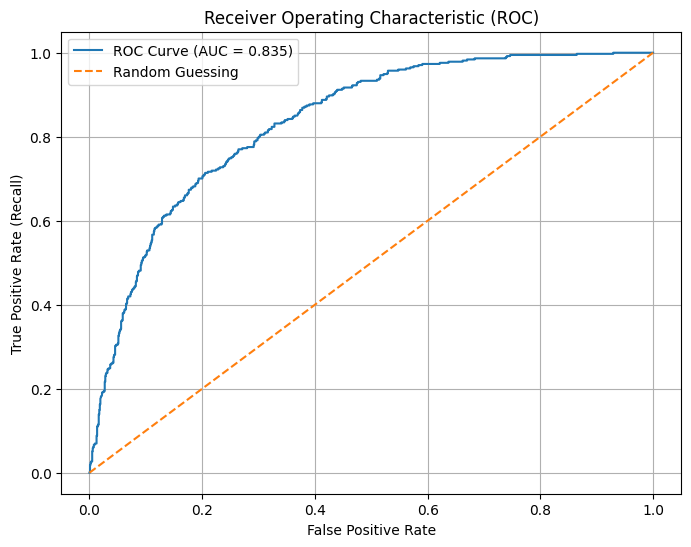

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# compute model probabilities
proba = pipe_lr.predict_proba(X_test)[:, 1]

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, proba)

# AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.grid(True)
plt.show()


## How to check the significant churn predictors using coefficients?


In [ ]:
print(all_iv_names)

['gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'Payment

In [ ]:
len(all_iv_names)

45

In [ ]:
main_model = pipe_lr.named_steps['clf']
main_model.coef_[0]

array([ 1.04213386e-01,  9.20282487e-02,  1.17563562e-01,  7.86780725e-02,
        2.11376853e-01, -1.51352178e-02,  5.55988707e-02,  1.40642764e-01,
       -1.24492060e-01,  5.55988707e-02,  2.65134825e-01, -5.16330345e-01,
        8.74762364e-01, -1.62190384e-01,  3.27797756e-01, -1.62190384e-01,
        3.06342632e-02,  2.08854737e-01, -1.62190384e-01,  1.49577282e-01,
        1.17405756e-01, -1.62190384e-01,  2.41026264e-01,  3.06171631e-01,
       -1.62190384e-01,  5.22603880e-02, -6.51269251e-02, -1.62190384e-01,
        4.23558944e-01, -5.80525277e-02, -1.62190384e-01,  4.16484547e-01,
        8.24436607e-01,  2.62332488e-02, -6.54428221e-01, -2.87555870e-02,
        2.24997222e-01, -8.52703384e-02, -1.27517572e-02,  3.24497382e-01,
       -3.02336524e-02,  2.03900103e-01, -5.24369213e-02, -2.67625859e-02,
        2.84180556e-04])

In [ ]:
coef = pipe_lr.named_steps['clf'].coef_[0]
importance_df = pd.DataFrame({
    'features': all_iv_names,
    'coefficients': coef
    }).sort_values('coefficients', ascending=False, key = abs)

In [ ]:
print(importance_df)

                                   features  coefficients
12              InternetService_Fiber optic      0.874762
32                  Contract_Month-to-month      0.824437
34                        Contract_Two year     -0.654428
11                      InternetService_DSL     -0.516330
28                          StreamingTV_Yes      0.423559
31                      StreamingMovies_Yes      0.416485
14                        OnlineSecurity_No      0.327798
39           PaymentMethod_Electronic check      0.324497
23                           TechSupport_No      0.306172
10                        MultipleLines_Yes      0.265135
22                     DeviceProtection_Yes      0.241026
36                     PaperlessBilling_Yes      0.224997
4                             Dependents_No      0.211377
17                          OnlineBackup_No      0.208855
41                            SeniorCitizen      0.203900
30      StreamingMovies_No internet service     -0.162190
27          St

## How to check the significant churn predictors using shap?


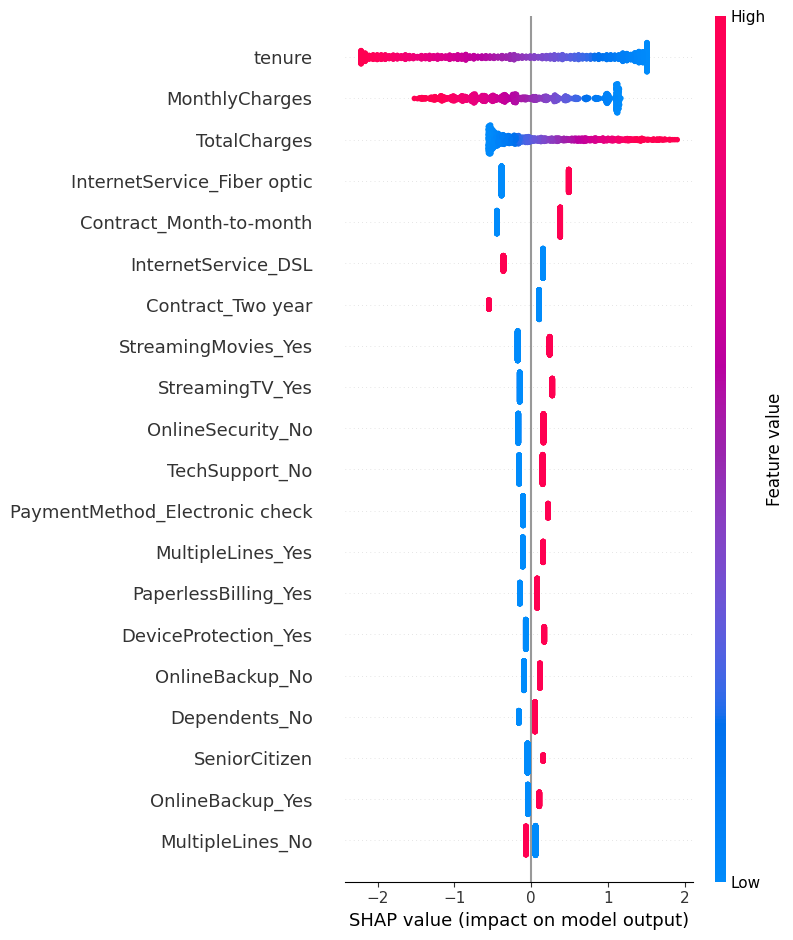

In [ ]:
import shap

model = pipe_lr.named_steps['clf']
X_transformed = pre.transform(X_test)
explainer = shap.Explainer(model, X_transformed)
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed, feature_names= all_iv_names)

# PDSML Day-11 👉 Exploratory Descritive Analysis

In [ ]:
df = pd.read_csv('Customer-Churn.csv')

In [ ]:
# Checking the numbers of rows and columns of a dataset
print(df.shape)

(7043, 21)


In [ ]:
# Checking the data types and non null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Checking the missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Checking the descriptive statistics for the numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Checking the categorical feature distribution
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [ ]:
#proportion
df['Contract'].value_counts(normalize=True)

,proportion
Contract,
Month-to-month,0.550192
Two year,0.240664
One year,0.209144


In [ ]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


<Axes: >

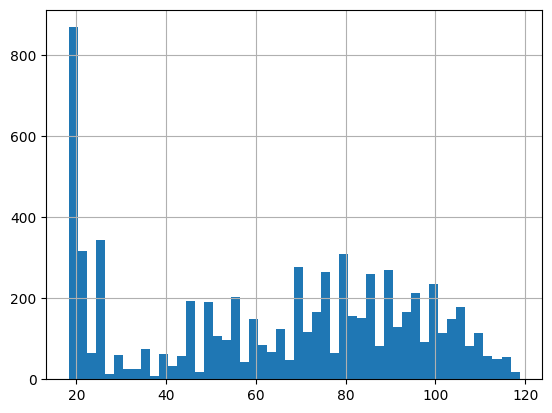

In [ ]:
# Checking the numeric feature distribution
df['MonthlyCharges'].hist(bins = 50)

In [ ]:
# Crosstabs analysis
pd.crosstab(df['Contract'], df['Churn'], normalize = 'index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [ ]:
# churn vs tenure
df['tenure_group'] = pd.cut(df['tenure'], bins = [0, 6, 12 , 24, 48, 72],
                            labels = ['0-6', '7-12', '13-24', '25-48', '49-72' ])
pd.crosstab(df['tenure_group'], df['Churn'])


Churn,No,Yes
tenure_group,,
0-6,686,784
7-12,452,253
13-24,730,294
25-48,1269,325
49-72,2026,213
